In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('.\data\data_encuesta.csv', sep=';')

df = df.drop("user_id", axis=1)

df.head()

,time_minutes,total_time(minutes)
0,30,180
1,45,180
2,40,120
3,15,120
4,35,600


In [20]:
df.shape

(32, 2)

In [21]:
df.describe()

,time_minutes,total_time(minutes)
count,32.000000,32.000000
mean,31.875000,151.875000
std,12.422015,143.761395
min,10.000000,60.000000
25%,22.500000,60.000000
50%,30.000000,90.000000
75%,40.000000,180.000000
max,50.000000,600.000000


In [22]:
mean = df.mean()
cov = df.cov()

rng = np.random.default_rng(seed=42)

sintectico = rng.multivariate_normal(mean, cov, size = 1500)
df_sintectico = pd.DataFrame(sintectico, columns=df.columns)

df_sintectico['time_minutes'] = round(df_sintectico['time_minutes'])
df_sintectico['total_time(minutes)'] = round(df_sintectico['total_time(minutes)'])
df_sintectico = df_sintectico[(df_sintectico > 0).all(axis=1)]
df_sintectico = df_sintectico[df_sintectico['total_time(minutes)'] >= 10]
df_sintectico = df_sintectico[df_sintectico['time_minutes'] >= 10]
df_sintectico = df_sintectico[df_sintectico['time_minutes'] < df_sintectico['total_time(minutes)']]

display(df_sintectico)

,time_minutes,total_time(minutes)
0,21.0,196.0
1,46.0,259.0
3,29.0,170.0
4,22.0,150.0
5,45.0,278.0
...,...,...
1494,49.0,183.0
1495,54.0,243.0
1496,60.0,143.0
1497,21.0,82.0


In [23]:
df_sintectico.describe()

,time_minutes,total_time(minutes)
count,1148.000000,1148.000000
mean,33.994774,200.764808
std,11.406799,108.959878
min,10.000000,19.000000
25%,26.000000,117.000000
50%,34.000000,187.000000
75%,42.000000,269.000000
max,74.000000,609.000000


In [24]:
df_union = pd.concat([df, df_sintectico])
df_union.head()

,time_minutes,total_time(minutes)
0,30.0,180.0
1,45.0,180.0
2,40.0,120.0
3,15.0,120.0
4,35.0,600.0


In [25]:
df_union.shape

display(df_union)

df_union.to_csv("datos.csv")

,time_minutes,total_time(minutes)
0,30.0,180.0
1,45.0,180.0
2,40.0,120.0
3,15.0,120.0
4,35.0,600.0
...,...,...
1494,49.0,183.0
1495,54.0,243.0
1496,60.0,143.0
1497,21.0,82.0


In [26]:
df_union.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1494     True
1495    False
1496    False
1497    False
1499    False
Length: 1180, dtype: bool

In [27]:
df_union.shape

(1180, 2)

In [28]:
df_union = df_union.sample(frac=1).reset_index(drop=True)

In [29]:

from sklearn.model_selection import train_test_split

train, test = train_test_split(df_union, test_size=0.2, random_state=42)

In [30]:
train.shape

(944, 2)

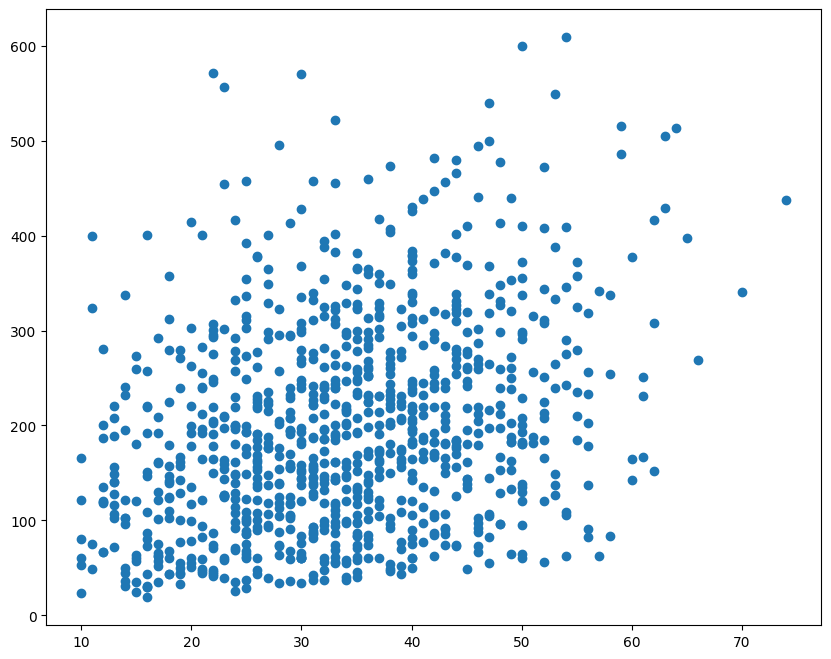

In [31]:
plt.figure(figsize=(10,8))
plt.scatter(train['time_minutes'], train['total_time(minutes)'])
plt.show()

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Valor de silueta para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Silueta')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Método del codo para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Suma de la distancia al cuadrado')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

Training model for K=2


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=3


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=4


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=5


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=6


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=7


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=8


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=9


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Training model for K=10


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


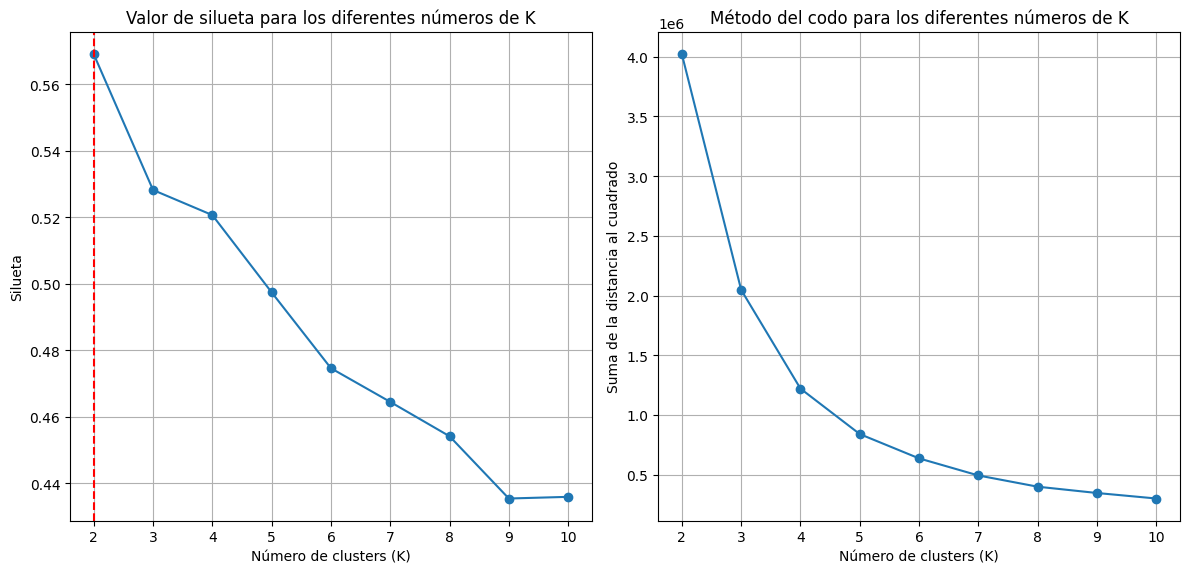

Optimal number of clusters: 2


2

In [33]:
find_optimal_k(train)

In [34]:
from sklearn.cluster import KMeans
K = 4

kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )

kmeans_model.fit(train)

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [35]:
cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

print(cluster_centers)

[[ 36.9650655  289.14847162]
 [ 33.92647059 182.6       ]
 [ 29.4047619   82.19047619]
 [ 40.58024691 432.86419753]]


In [36]:
cluster_centers = cluster_centers[np.argsort(cluster_centers[:, 0])]

print(cluster_centers)

[[ 29.4047619   82.19047619]
 [ 33.92647059 182.6       ]
 [ 36.9650655  289.14847162]
 [ 40.58024691 432.86419753]]


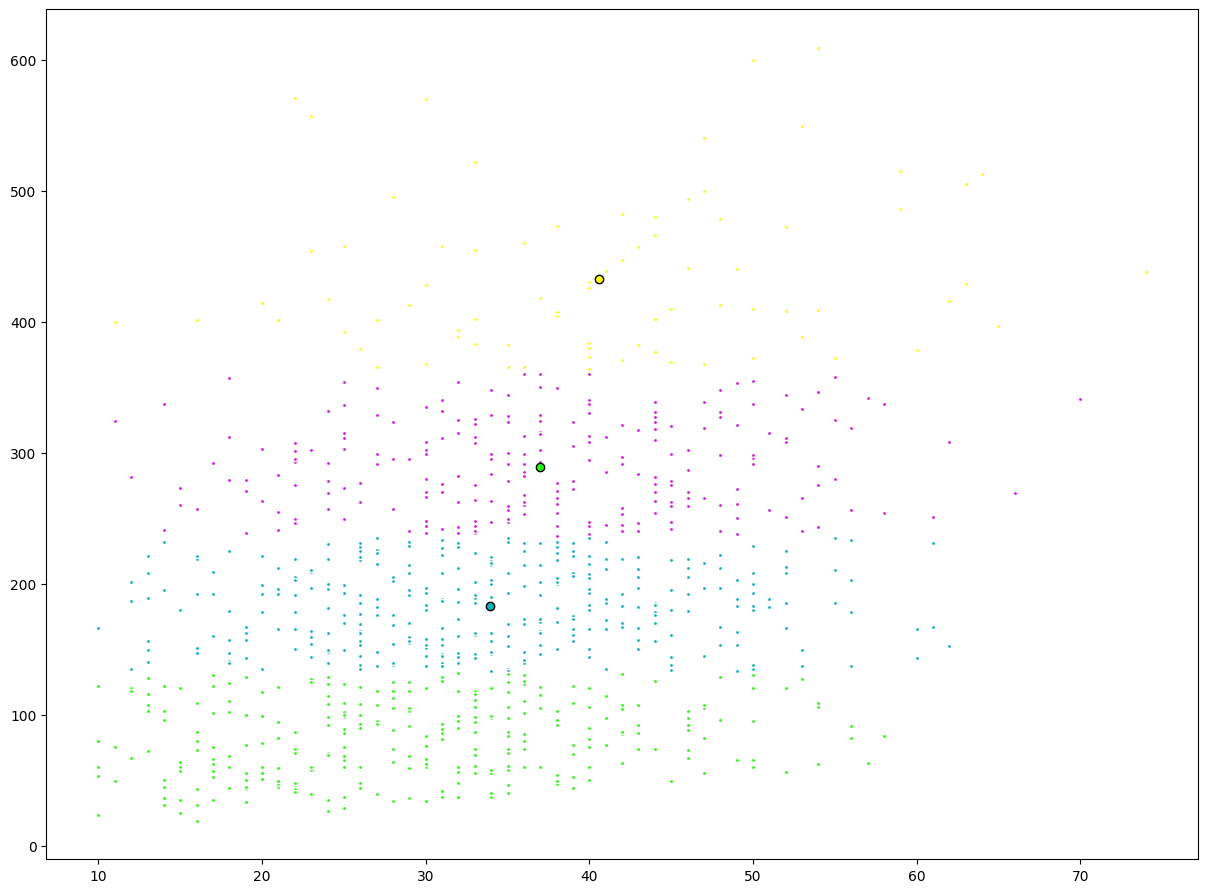

In [37]:
fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members = cluster_labels == k
    cluster_center = cluster_centers[k]
    plt.plot(train.iloc[my_members, 0], train.iloc[my_members, 1], "w", markerfacecolor=col, marker=".")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

In [38]:
from sklearn.cluster import MiniBatchKMeans
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k_mini(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = MiniBatchKMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Valor de silueta para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Silueta')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Método del codo para los diferentes números de K')
    plt.xlabel('Número de clusters (K)')
    plt.ylabel('Suma de la distancia al cuadrado')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

Training model for K=2


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=3


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=4


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=5


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=6


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=7


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=8


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=9


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Training model for K=10


c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


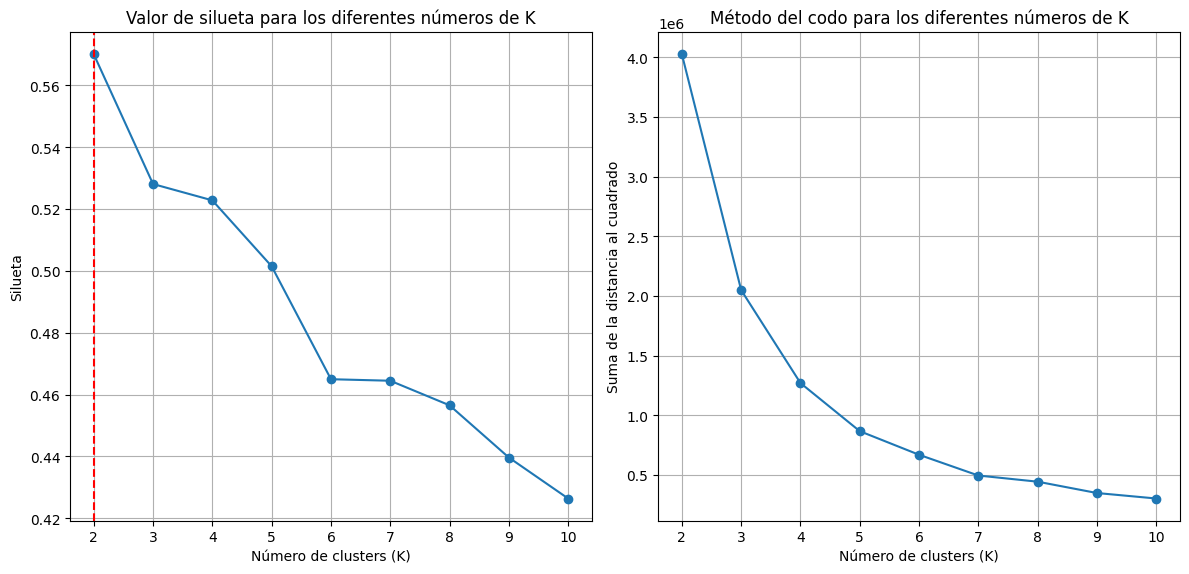

Optimal number of clusters: 2


2

In [39]:
find_optimal_k_mini(train)

In [73]:

minikmeans_model = MiniBatchKMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            random_state=42
            )

minikmeans_model.fit(train)

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2560 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,10


In [54]:
mincluster_labels = minikmeans_model.labels_
mincluster_centers = minikmeans_model.cluster_centers_

print(mincluster_centers)

[[ 37.2804428  315.38660233]
 [ 29.71064468  88.91037814]
 [ 34.55409133 199.30125651]
 [ 41.82021277 461.72765957]]


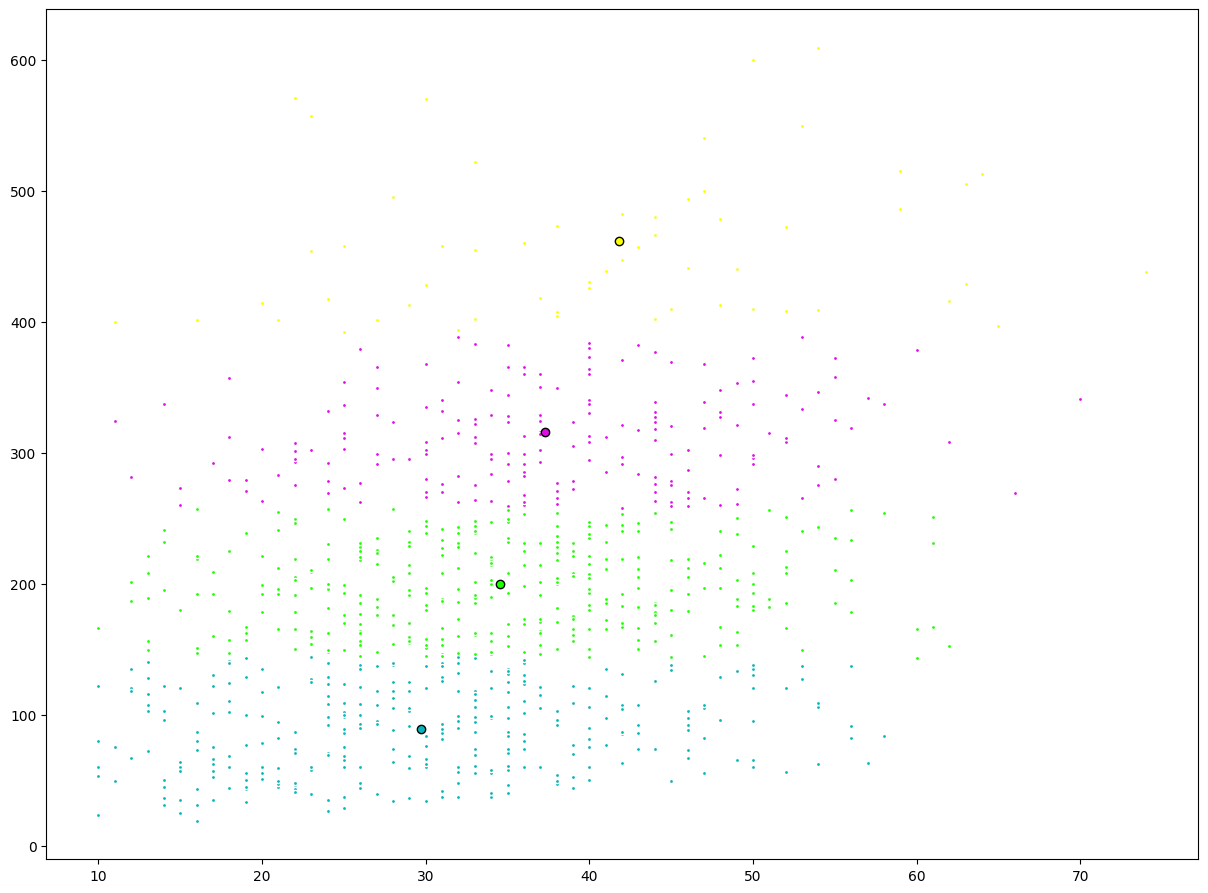

In [42]:
fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members = mincluster_labels == k
    cluster_center = mincluster_centers[k]
    plt.plot(train.iloc[my_members, 0], train.iloc[my_members, 1], "w", markerfacecolor=col, marker=".")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

In [74]:

for i in range(14):
    for _, data in test.iterrows():
        minikmeans_model._counts[:] = 18
        minikmeans_model.partial_fit(data.values.reshape(1, -1))
    

c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with feature names
  warnings.warn(
c:\Users\celia\anaconda3\envs\master\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MiniBatchKMeans was fitted with f

In [77]:
mincluster_labels = minikmeans_model.labels_
mincluster_centers = minikmeans_model.cluster_centers_

print(mincluster_centers)

[[ 36.05129117 281.72544524]
 [ 32.71552369  82.87589828]
 [ 33.87356351 171.24241865]
 [ 38.85193728 411.77190819]]


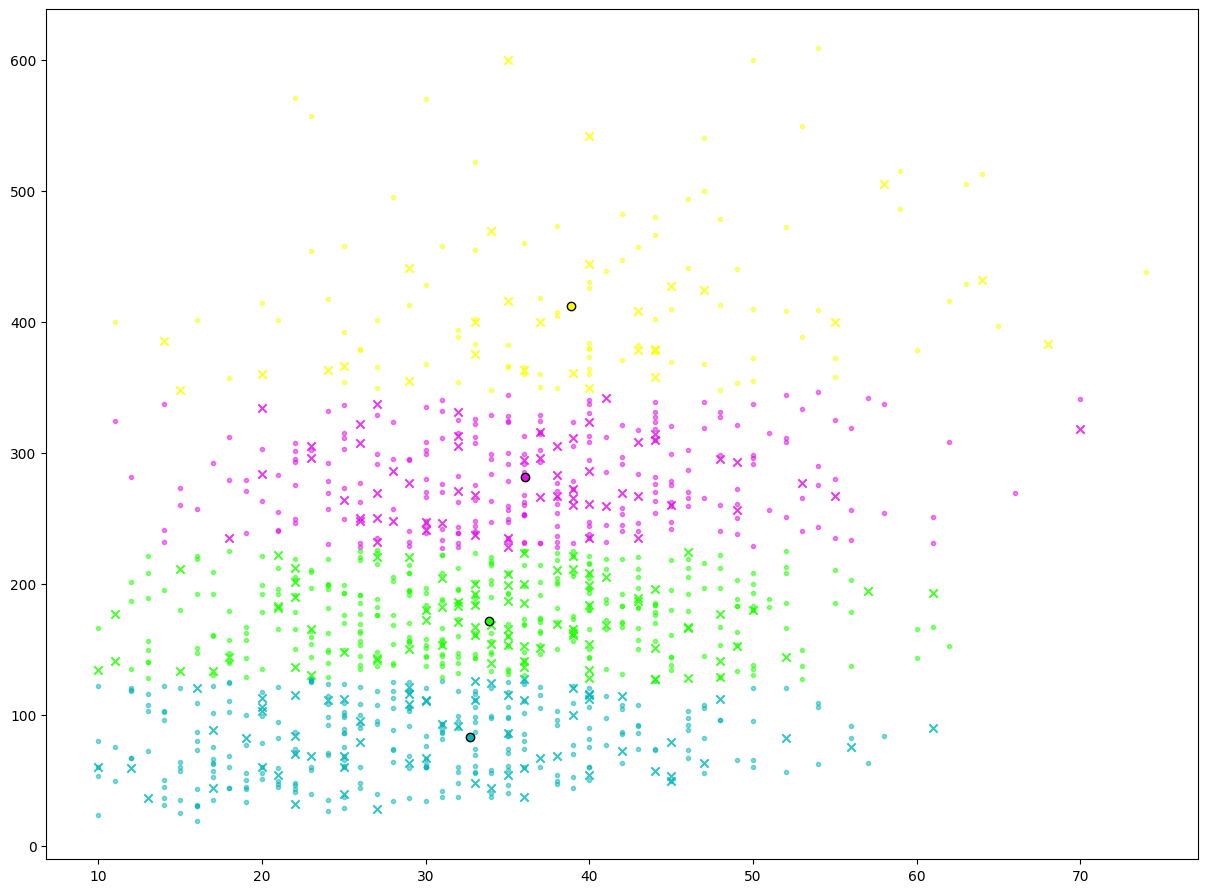

In [78]:
label_train = minikmeans_model.predict(train)
label_test = minikmeans_model.predict(test)

fig = plt.figure(figsize=(12,10))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ["#DF0FE6", "#06B5B8","#1EFF00","#FBFF00" ]
for k, col in zip(range(4), colors):
    my_members_train = label_train == k 
    my_members_test = label_test == k
    cluster_center = mincluster_centers[k]
    plt.scatter(train.iloc[my_members_train, 0], train.iloc[my_members_train, 1], alpha = 0.5, color=col, marker=".")
    plt.scatter(test.iloc[my_members_test, 0], test.iloc[my_members_test, 1],  alpha = 0.8, color=col, marker="x")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=6,
    )

plt.show()

In [67]:
from sklearn.metrics.pairwise import pairwise_distances_argmin

mincluster_labels_train = minikmeans_model.predict(train)
order = pairwise_distances_argmin(kmeans_model.cluster_centers_, minikmeans_model.cluster_centers_)
remapped_mini_labels = order[mincluster_labels_train]
print("Mapeo KMeans → MiniBatch:", order)

k_means_labels = pairwise_distances_argmin(train, cluster_centers)
mbk_means_labels = pairwise_distances_argmin(train, mincluster_centers)

Mapeo KMeans → MiniBatch: [0 2 1 3]


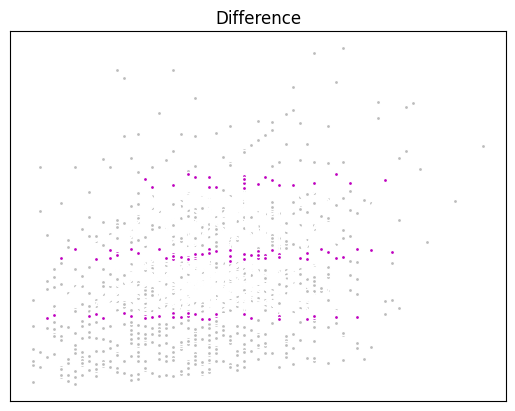

In [69]:
different = cluster_labels != remapped_mini_labels
    
identical = np.logical_not(different)
plt.plot(train.iloc[identical, 0], train.iloc[identical, 1], "w", markerfacecolor="#bbbbbb", marker=".")
plt.plot(train.iloc[different, 0], train.iloc[different, 1], "w", markerfacecolor="m", marker=".")
plt.title("Difference")
plt.xticks(())
plt.yticks(())

plt.show()

In [68]:
print("Centros KMeans (originales):")
for i, c in enumerate(kmeans_model.cluster_centers_):
    print(f"  KM {i}: total_time={c[1]:.1f}")

print("\nCentros MiniBatch (actuales):")
for i, c in enumerate(minikmeans_model.cluster_centers_):
    print(f"  MBK {i}: total_time={c[1]:.1f}")

print("\nMapeo:", order)

# Analizar los puntos del cluster superior (KM cluster 3)
upper_idx = np.where(cluster_labels == 3)[0]
print(f"\nPuntos en KMeans cluster 3 (arriba): {len(upper_idx)}")
print(f"MiniBatch los predice como clusters:", np.unique(mincluster_labels_train[upper_idx], return_counts=True))
print(f"Tras remap, quedan como clusters:", np.unique(remapped_mini_labels[upper_idx], return_counts=True))
print(f"¿Cuántos marcados como 'different'?: {different[upper_idx].sum()} de {len(upper_idx)}")


Centros KMeans (originales):
  KM 0: total_time=289.1
  KM 1: total_time=182.6
  KM 2: total_time=82.2
  KM 3: total_time=432.9

Centros MiniBatch (actuales):
  MBK 0: total_time=315.4
  MBK 1: total_time=88.9
  MBK 2: total_time=199.3
  MBK 3: total_time=461.7

Mapeo: [0 2 1 3]

Puntos en KMeans cluster 3 (arriba): 81
MiniBatch los predice como clusters: (array([0, 3]), array([24, 57], dtype=int64))
Tras remap, quedan como clusters: (array([0, 3], dtype=int64), array([24, 57], dtype=int64))
¿Cuántos marcados como 'different'?: 81 de 81


In [70]:
len(test)

236